In [1]:
import os
# Get the current working directory
current_dir = os.getcwd()
# Set the data directory to the parent directory of the current working directory
wdir = os.path.dirname(current_dir)
# Change the current working directory to the parent directory
os.chdir(wdir)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import rcParams


In [2]:
# Set the font globally
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 9
rcParams['axes.titlesize'] = 9
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9

In [6]:

# --------------------
# Load data
# --------------------
av_num_mut_no_cd = np.loadtxt(
    "data/Supplementary_Fig_11/av_num_mut_mu_025_M10000_no_cd.txt"
)

av_num_mut_cd_with_mut_burst = np.loadtxt(
    "data/Supplementary_Fig_11/av_num_mut_mu_025_M10000_cd.txt"
)


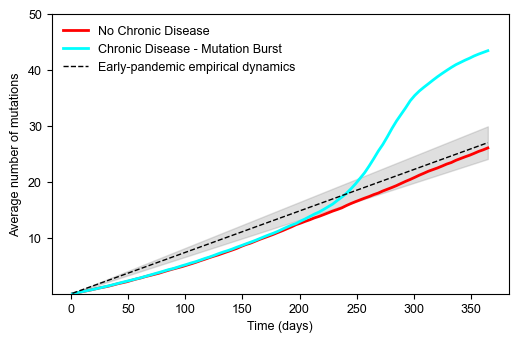

In [7]:
def cm2inch(x): return float(x)/2.54

plotwidth    = cm2inch(8.90)

#--------------------
# Parameters
# --------------------
T = 365
days = np.arange(1, T + 1)

rate_low  = 0.066
rate_high = 0.082
rate_mid  = 0.5 * (rate_low + rate_high)

# Central line and ribbon
line = rate_mid * days
lower_ribbon = (rate_mid - rate_low) * days
upper_ribbon = (rate_high - rate_mid) * days

# Sampling every 4 days (Julia: 1:4:T+1)
idx = np.arange(0, T, 4)
time_sampled = idx + 1

# --------------------
# Plot
# --------------------
fig, ax = plt.subplots(figsize=(1.5*plotwidth, plotwidth))

ax.plot(
    time_sampled,
    av_num_mut_no_cd[idx],
    linewidth=2,color='red',
    label="No Chronic Disease"
)

ax.plot(
    time_sampled,
    av_num_mut_cd_with_mut_burst[idx],
    linewidth=2,color='cyan',
    label="Chronic Disease - Mutation Burst"
)

# Midpoint line with ribbon
ax.plot(
    days,
    line,
    linestyle="--",
    color='black',
    linewidth=1,
    label="Early-pandemic empirical dynamics"
)

ax.fill_between(
    days,
    line - lower_ribbon,
    line + upper_ribbon,
    alpha=0.25,color='gray',
)

# --------------------
# Formatting
# --------------------
ax.set_xlabel("Time (days)")
ax.set_ylabel("Average number of mutations")
ax.set_ylim(0.001, 50)

ax.legend(loc="upper left", frameon=False)
ax.grid(False)

# Boxed frame (Julia: frame=:box)
for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()
